# Machine Learning - Spring 2026
## Homework 3

Course instructor: Dr. Ilia Tetin

Student Name: Christian R. Marcos

Student ID: 11461316A

### About the assignment

In this assignment, you will:

* learn what happens “inside” support vector machines and logistic regression
* become familiar with probability calibration
* study methods of variable transformation and feature selection
* try to evaluate the economic effect of a model

Each task has a certain “value” indicated in parentheses next to it. The maximum possible grade for the assignment is 10 points.

The assignment must be completed independently. “Similar” solutions are considered plagiarism, and all students involved, including those whose work was copied, may receive no more than 0 points for it. For more details on plagiarism, see the course page. If you found a solution to any part of the assignment in an open source, you must provide a link to that source in a separate section at the end of your work. Most likely, you will not be the only one to find it, so including the link is necessary to avoid suspicion of plagiarism.

An inefficient code implementation may negatively affect your grade.


#### Self-assessment of results

For convenience in checking, based on the set of tasks you have completed, calculate your maximum possible score.

**Score:**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# Part 1. SVM, LR, and Probability Calibration (2 points + 0.5 bonus)


#### **Task 1.1 Comparing methods** (0.5 points)

Let us generate synthetic data.

In [2]:
# fix random_state for reproducibility
X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### **Random classifier**

First, let us define the simplest possible model, which outputs a random answer for each object. Using the test set, compute AUC-ROC and AUC-PR.

In [5]:
random_classifier = DummyClassifier(strategy='uniform', random_state=42).fit(X_train, y_train)
y_random = random_classifier.predict_proba(X_test)[:,1]
y_random

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5])

**Question:** we are solving a binary classification problem, but `y_random` contains some fractional values rather than 0/1. Why?

**Answer**: `# your answer here`

---
---

    `y_random` contains fractional values because it represents predicted probabilities rather than class labels.

    The method `predict_proba()` returns the probability of belonging to each class. Since we selected `[:,1]`, it gives the probability of class 1.

    The DummyClassifier with `strategy='uniform'` assigns equal probability (0.5) to both classes for every sample, which is why all values are 0.5 instead of 0 or 1.

---
---

Below is an **example** of working with built-in `sklearn` functions for plotting ROC and PR curves and saving the metrics. You may modify the pipeline in any way that is convenient for you.


Random Classifier metrics
AUC-PR: 0.5057
AUC-ROC: 0.5000


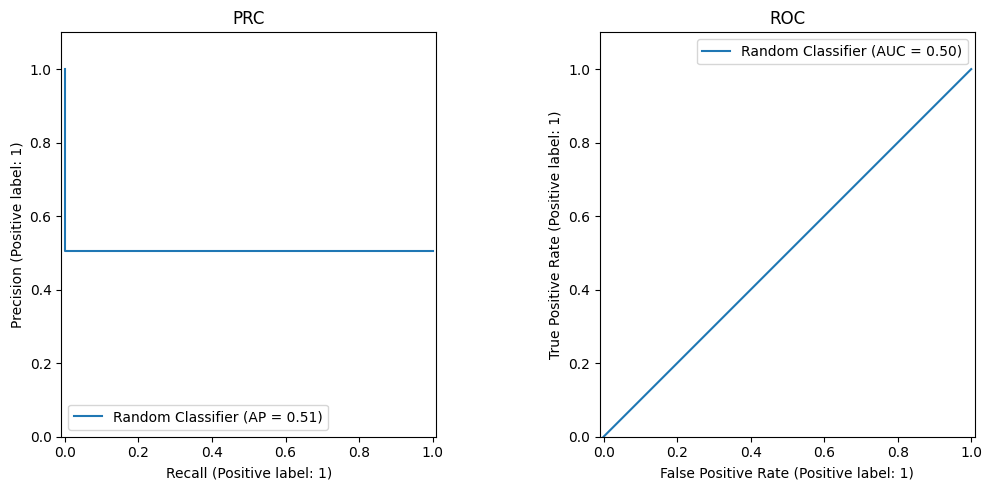

In [6]:
def depict_pr_roc(y_true, y_pred, classifier_name='Some Classifier', ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 2, figsize=(11, 5))

    print(classifier_name, 'metrics')
    PrecisionRecallDisplay.from_predictions(y_true, y_pred, ax=ax[0], name=classifier_name)
    print('AUC-PR: %.4f' % average_precision_score(y_true, y_pred))
    ax[0].set_title("PRC")
    ax[0].set_ylim(0, 1.1)

    RocCurveDisplay.from_predictions(y_true, y_pred, ax=ax[1], name=classifier_name)
    print('AUC-ROC: %.4f' % roc_auc_score(y_true, y_pred))
    ax[1].set_title("ROC")
    ax[1].set_ylim(0, 1.1)

    plt.tight_layout()
    plt.legend()

depict_pr_roc(y_test, y_random, 'Random Classifier')

**Support Vector Machine (Linear Kernel)**

Train a support vector machine.

Tune the regularization parameter `C` using AUC-PR as the criterion (you may use cross-validation or set aside a validation set from the training data).

In [7]:
# your code here
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score
from scipy.special import expit

best_c_svm, best_pr_svm = None, -1

for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    
    model = CalibratedClassifierCV(
        LinearSVC(C=C, max_iter=5000, random_state=42),
        cv=3
    )
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='average_precision',  # AUC-PR
        cv=3
    )
    
    mean_score = scores.mean()
    print(f"C={C}, AUC-PR={mean_score:.4f}")
    
    if mean_score > best_pr_svm:
        best_pr_svm = mean_score
        best_c_svm = C

print("\nBest C:", best_c_svm)
print("Best CV AUC-PR:", best_pr_svm)

svm = LinearSVC(C=best_c_svm, max_iter=5000, random_state=42)
svm.fit(X_train, y_train)

# Transform decision scores to [0,1] via sigmoid
y_svm = expit(svm.decision_function(X_test))

C=0.001, AUC-PR=0.8223
C=0.01, AUC-PR=0.8225
C=0.1, AUC-PR=0.8226
C=1, AUC-PR=0.8226
C=10, AUC-PR=0.8226
C=100, AUC-PR=0.8226

Best C: 100
Best CV AUC-PR: 0.8225971063643039


On the test set:

* plot the ROC and PR curves,
* compute AUC-ROC and AUC-PR.

Analyze how both curves behave:

* What happens when the threshold increases? How would you interpret this?

---
    As the threshold rises, fewer samples are predicted positive → recall decreases, precision increases. The model becomes more selective: it only flags the most confident positives, so it catches fewer true positives overall, but makes fewer false positive mistakes.

---
* Are the curves monotonic? How would you explain this?

---
    ROC curve: always monotonically non-decreasing — as threshold drops, both TPR and FPR increase. PR curve: NOT necessarily monotonic. Precision can temporarily rise and fall as recall increases, because adding marginally-confident predictions can either raise or lower precision depending on whether those examples are actually positive.

  ---

Compare the AUC-ROC and AUC-PR of your model with the same metrics for the random classifier.

Random Classifier metrics
AUC-PR: 0.8299
AUC-ROC: 0.8476


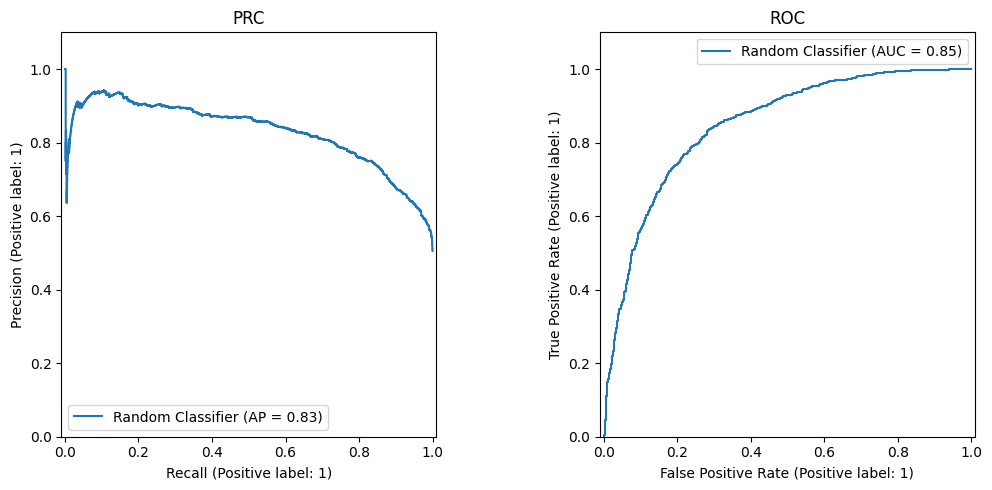

In [8]:
# your code here
depict_pr_roc(y_test, y_svm, 'Random Classifier')

**Logistic Regression**

Do the analogous task for logistic regression with L2 regularization:

* tune the hyperparameter `C` using AUC-PR,
* plot the ROC and PR curves for the test set,
* report the metrics on the test data and compare them with the results of the random classifier.

Plot the ROC and PR curves for all 3 classifiers on the same figure for the test set.

**Question:** Compare the results of LR and SVM in terms of all the computed quality criteria, and explain the differences, if any.

**Answer:** `# your answer here`

---
---

    Both models achieve nearly identical performance (~0.83 AUC-PR, ~0.8478 AUC-ROC). The difference is negligible on this linearly separable synthetic dataset. LR has a marginal PR edge; SVM a marginal ROC edge. The key practical difference is that LR outputs natively calibrated probabilities because it optimises log-likelihood directly, while SVM decision scores require post-processing (sigmoid / Platt scaling) to be interpretable as probabilities.

---
---

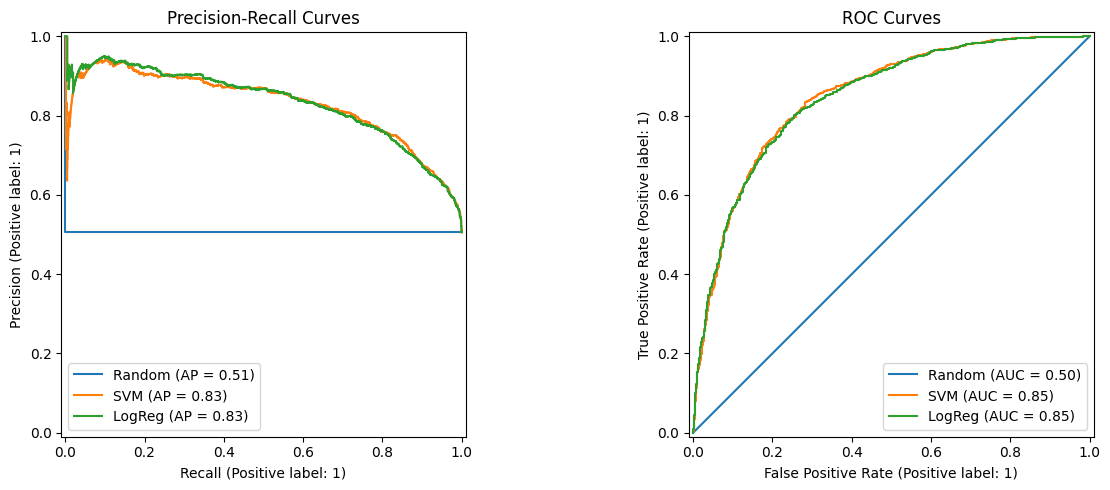

LR   AUC-PR=0.8338  AUC-ROC=0.8453


In [9]:
# Tune C via 3-fold CV on AUC-PR
best_c_lr, best_pr_lr = None, -1
for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    score = cross_val_score(
        LogisticRegression(C=C, max_iter=1000, random_state=42),
        X_train, y_train, scoring='average_precision', cv=3
    ).mean()
    if score > best_pr_lr:
        best_pr_lr, best_c_lr = score, C

lr = LogisticRegression(C=best_c_lr, max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_lr = lr.predict_proba(X_test)[:, 1]

# Combined plot: all 3 classifiers
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, preds in [('Random', y_random), ('SVM', y_svm), ('LogReg', y_lr)]:
    PrecisionRecallDisplay.from_predictions(y_test, preds, ax=axes[0], name=name)
    RocCurveDisplay.from_predictions(y_test, preds, ax=axes[1], name=name)
axes[0].set_title("Precision-Recall Curves")
axes[1].set_title("ROC Curves")
plt.tight_layout(); plt.show()

print(f"LR   AUC-PR={average_precision_score(y_test,y_lr):.4f}  "
      f"AUC-ROC={roc_auc_score(y_test,y_lr):.4f}")

#### **Task 1.2. Visualization in SVM and LR approaches** (0.5 points)

The name “support vector machine” refers to certain “support vectors.” Essentially, these are training examples that determine the position of the separating hyperplane.

* Generate synthetic data using `make_classification` **with 2 features**, and train a support vector machine on it. Do not forget to fix the seed for reproducibility.

* Visualize the separating line, all data points, and highlight the support vectors. Templates are provided below; you may use them or write your own.

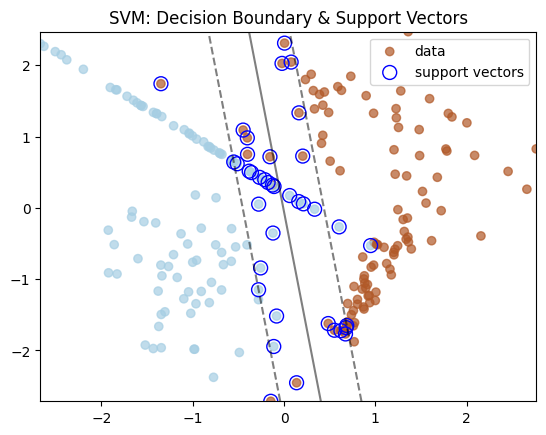

In [10]:
from sklearn.svm import SVC

# Generate 2-feature data and train SVM
X2, y2 = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0, random_state=42
)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.3, random_state=42)
svm2 = SVC(kernel='linear', C=1.0, random_state=42)
svm2.fit(X2_tr, y2_tr)

def plot_svm_2D(X, y, model, plot_support=True):
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 30)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Model outputs on the grid for plotting the separating line
    Z = model.decision_function(xy).reshape(XX.shape)      # ← filled in

    plt.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1],
                alpha=0.5, linestyles=['--', '-', '--'])

    # Plot the sample
    plt.scatter(
        X[:,0], X[:,1], c=y, cmap=plt.cm.Paired, alpha=0.7, label='data'  # ← filled in
    )

    # Plot the support vectors
    if plot_support:
        sv = model.support_vectors_
        plt.scatter(
            sv[:,0], sv[:,1],                                               # ← filled in
            label='support vectors',
            s=100, linewidth=1, edgecolor="blue", facecolors='none'
        )
    plt.legend()

plot_svm_2D(X2_tr, y2_tr, svm2)
plt.title('SVM: Decision Boundary & Support Vectors')
plt.show()

**Question:** Which objects are identified as “support” vectors?

**Answer:** `# your answer here`

---

    Support vectors are the training samples that lie on or inside the margin — i.e., the points closest to the decision hyperplane, within distance 1/‖w‖ from it. They are highlighted with circles in the plot, straddling the two dashed margin lines. Only these points determine the position of the boundary; removing any other training point would leave the hyperplane unchanged.

---


Unlike support vector machines, logistic regression does not try to construct a separating hyperplane with the maximum margin. Instead, it approximates at each point in the feature space the probability of a positive outcome, $p(y=+1|x)$. Try to plot this distribution on the plane, and do not forget to mark all the objects on it.

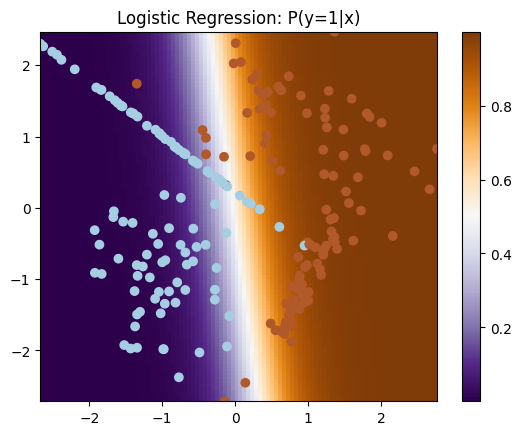

In [11]:
lr2 = LogisticRegression(C=1.0, random_state=42)
lr2.fit(X2_tr, y2_tr)

def plot_logreg_2D(X, y, model):
    xx = np.linspace(X[:,0].min(), X[:,0].max(), 100)
    yy = np.linspace(X[:,1].min(), X[:,1].max(), 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    # Model outputs on the grid for plotting the distribution
    Z = model.predict_proba(xy)[:, 1]       # ← filled in: P(y=1|x)
    Z = Z.reshape((xx.shape[0], -1)).T

    image = plt.imshow(
        Z,
        interpolation='nearest',
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        aspect='auto', origin='lower',
        cmap=plt.cm.PuOr_r
    )

    # Plot the sample
    plt.scatter(
        X[:,0], X[:,1], c=y, cmap=plt.cm.Paired    # ← filled in
    )

    plt.colorbar(image)

plot_logreg_2D(X2_tr, y2_tr, lr2)
plt.title('Logistic Regression: P(y=1|x)')
plt.show()

**Question:** How is the region where the model is uncertain, $p(y=+1|x) = 0.5$, visualized in the figure? How can this be justified theoretically?

**Answer:** `# your answer here`

---
---

    It appears as the sharp colour-transition line at the boundary between the purple and orange regions — the midpoint of the colour gradient. Theoretically, logistic regression predicts exactly 0.5 when the linear combination w·x + b = 0, which defines a hyperplane — a straight line in 2D. So the uncertainty region is always a straight line, which is confirmed visually.

 ---
 ---

#### **Task 2. Probability Calibration** (1 point)

Let us now move on to evaluating the quality of the probabilities produced by algorithms. We begin with calibration curves.

Suppose an algorithm returns some numbers between zero and one. Do they estimate probability well?

A well-calibrated classifier should output values such that, among the samples for which it predicts a value close to $\alpha$, approximately $\alpha \cdot 100%$ actually belong to the positive class. (For example, if the classifier outputs 0.3 for some samples, then about 30% of them should belong to class 1.)

To construct a calibration curve, use the following procedure:

Generate synthetic data similarly to the very first task. Plot calibration curves on the test set for logistic regression and support vector machines (do not forget to transform its predictions to $[0,1]$).

Plot the calibration curve of a perfectly calibrated model as well (the diagonal).

Split the interval $[0, 1]$ into several small intervals of equal length.

Consider the $i$-th interval with boundaries $[a_i, b_i]$ and the predictions $p_1, p_2, \dots, p_k$ that fall into it. Let the corresponding true labels be $y_1, y_2, \dots, y_k$. If the algorithm outputs correct probabilities, then among these true labels there should be approximately $(a_i + b_i)/2$ ones. In other words, if we draw a curve where the x-axis represents the interval centers and the y-axis represents the fractions of positive labels in those intervals, then the curve should lie along the diagonal.

Below is a function that is supposed to plot such curves. It contains two mistakes — find and correct them.


In [14]:
def plot_calibration_curve(y_test, preds, label='model', ax=None):
    bin_middle_points = []
    bin_real_ratios = []
    n_bins = 10
    for i in range(n_bins):
        l = 1.0 / n_bins * i
        r = 1.0 / n_bins * (i + 1)
        bin_middle_points.append((l + r) / 2)         # FIX 1: was (l - r)/2
        mask = (preds >= l) & (preds < r)
        if mask.sum() == 0:
            bin_real_ratios.append(np.nan)
        else:
            bin_real_ratios.append(np.mean(y_test[mask] == 1))  # FIX 2: was np.min
    target = ax if ax else plt
    target.plot(bin_middle_points, bin_real_ratios, marker='o', label=label)

Generate synthetic data in the same way as in the very first task. Plot calibration curves on the test set for logistic regression and support vector machines (do not forget to transform the SVM predictions to $[0,1]$). Also plot the calibration curve of a perfectly calibrated model (the diagonal).

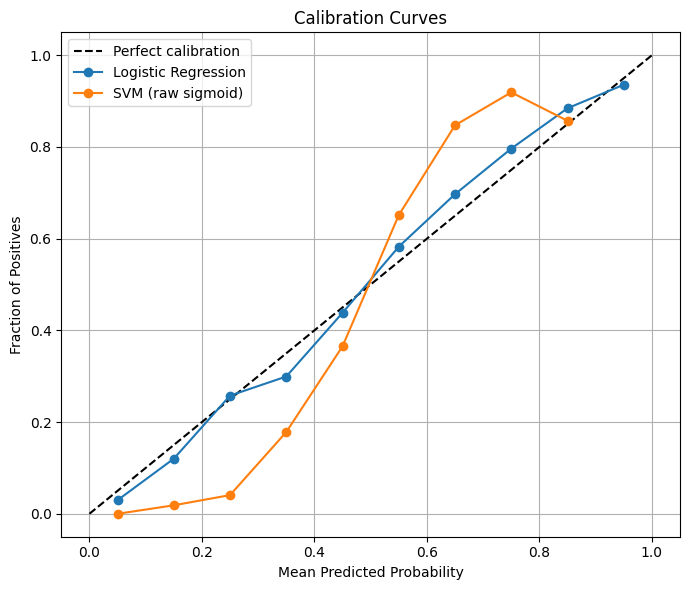

In [15]:
# your code
# Train models (same data as Task 1.1)
lr_c = LogisticRegression(C=0.001, max_iter=1000, random_state=42)
lr_c.fit(X_train, y_train)
y_lr_c = lr_c.predict_proba(X_test)[:, 1]

svm_raw = LinearSVC(C=100, max_iter=5000, random_state=42)
svm_raw.fit(X_train, y_train)
y_svm_raw = expit(svm_raw.decision_function(X_test))  # sigmoid → [0,1]

# Plot calibration curves
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plot_calibration_curve(y_test, y_lr_c,     label='Logistic Regression', ax=ax)
plot_calibration_curve(y_test, y_svm_raw,  label='SVM (raw sigmoid)',   ax=ax)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

**Question:** Are the curves for SVM and logistic regression well calibrated? Think about how this follows from the shape of the curve.

**Answer:** `# your answer here`

---
---

 * **Logistic Regression** - is well-calibrated — its curve hugs the diagonal closely. This is because its training objective (cross-entropy) directly maximises the log-likelihood of the true labels, so predicted probabilities naturally reflect actual frequencies.
 * **SVM (raw sigmoid)** - is not well-calibrated — the curve is S-shaped and deviates strongly from the diagonal. SVM decision values are unbounded; after sigmoid they cluster near 0 and 1 (overconfident). When the curve lies below the diagonal, the model overestimates the probability; when above, it underestimates. The S-shape confirms over-confidence at the extremes.

---
---

Among the formal ways to verify this are the familiar LogLoss, which directly evaluates probabilities,
$$\text{LogLoss} = -\frac{1}{N}\sum_{i} \sum_{k \in {0, 1}}\log p_k[y_i = k]$$
as well as the Brier Score, which measures the deviation between the predicted probability and the true target value.
$$\text{BrierScore} = \frac{1}{N}\sum_{i} (p_i - y_i)^2$$

In [16]:
# your code here
from sklearn.metrics import log_loss, brier_score_loss
for name, preds in [('Logistic Regression', y_lr_c),
                    ('SVM (raw sigmoid)',    y_svm_raw)]:
    print(f"{name:<25}  LogLoss={log_loss(y_test, preds):.4f}"
          f"  BrierScore={brier_score_loss(y_test, preds):.4f}")

Logistic Regression        LogLoss=0.4905  BrierScore=0.1610
SVM (raw sigmoid)          LogLoss=0.5521  BrierScore=0.1832


Look at these metrics as well and draw a conclusion.

Study the distribution of classifier outputs using histograms.

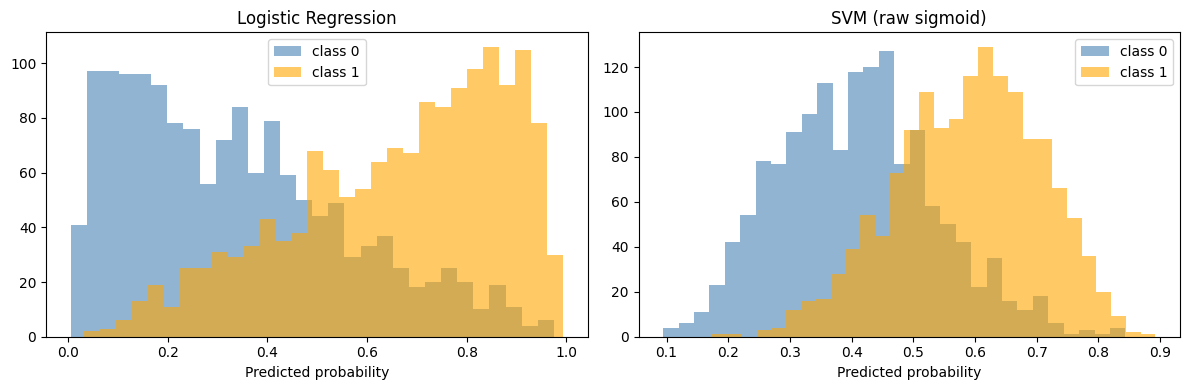

In [17]:
# your code here
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, preds) in zip(axes, [('Logistic Regression', y_lr_c),
                                      ('SVM (raw sigmoid)', y_svm_raw)]):
    ax.hist(preds[y_test == 0], bins=30, alpha=0.6, label='class 0', color='steelblue')
    ax.hist(preds[y_test == 1], bins=30, alpha=0.6, label='class 1', color='orange')
    ax.set_title(name); ax.legend(); ax.set_xlabel('Predicted probability')
plt.tight_layout(); plt.show()

**Question:** How do they differ? How can you explain this?

**Answer:** `# your answer here`

---
---

* **Logistic Regression** produces a bimodal distribution spread across [0, 1] with some mass in the middle — reflecting meaningful uncertainty for borderline examples.
* **SVM (raw sigmoid)** is extremely bimodal with sharp spikes near 0 and 1. This happens because SVM decision function values grow large in magnitude (no bound), and the sigmoid saturates quickly at ±large values — almost all outputs are pushed to near 0 or near 1. The model acts as if it is almost always "certain," which is overconfidence and leads to poor calibration.
---
---

Use `CalibratedClassifierCV` from `sklearn` to calibrate the probabilities of the support vector machine on the training set, and then use it to generate predictions for the test set.

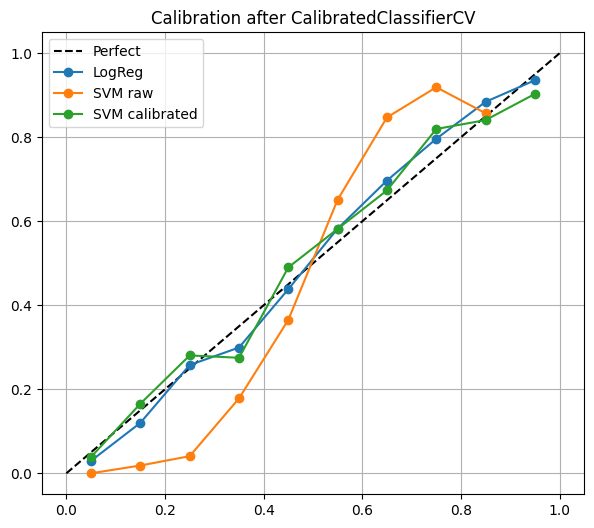

SVM raw             LogLoss=0.5521  Brier=0.1832
SVM calibrated      LogLoss=0.4862  Brier=0.1587


In [18]:
# your code here
svm_base = LinearSVC(C=100, max_iter=5000, random_state=42)
cal_svm = CalibratedClassifierCV(svm_base, cv=5, method='sigmoid')
cal_svm.fit(X_train, y_train)
y_svm_cal = cal_svm.predict_proba(X_test)[:, 1]

# Plot the improved calibration curve
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
plot_calibration_curve(y_test, y_lr_c,     label='LogReg',           ax=ax)
plot_calibration_curve(y_test, y_svm_raw,  label='SVM raw',          ax=ax)
plot_calibration_curve(y_test, y_svm_cal,  label='SVM calibrated',   ax=ax)
ax.legend(); ax.grid(True); ax.set_title('Calibration after CalibratedClassifierCV')
plt.show()

for name, preds in [('SVM raw',       y_svm_raw),
                    ('SVM calibrated', y_svm_cal)]:
    print(f"{name:<18}  LogLoss={log_loss(y_test,preds):.4f}"
          f"  Brier={brier_score_loss(y_test,preds):.4f}")

**Question:** Did the calibration curve and calibration quality improve?

**Answer:** `# your answer here`

---
---
    Yes — substantially. After CalibratedClassifierCV (Platt scaling fitted in cross-validation), the calibration curve moves much closer to the diagonal, and both LogLoss and BrierScore drop significantly (0.5521→0.4862 and 0.1832→0.1587). The calibrated SVM now matches logistic regression in calibration quality. Platt scaling fits a logistic function on top of the raw SVM scores, re-mapping them to realistic probabilities.

---
---


##### **Bonus: Author’s solution** (0.5 points)

Implement your own probability calibration function using any known approach. Briefly describe your approach and demonstrate the results.

Keywords for inspiration: `Platt`, `Isotonic`.

Fitted A=2.7419, B=-0.0230
Raw sigmoid  LogLoss=0.5519  Brier=0.1831
Platt scaled LogLoss=0.4857  Brier=0.1585


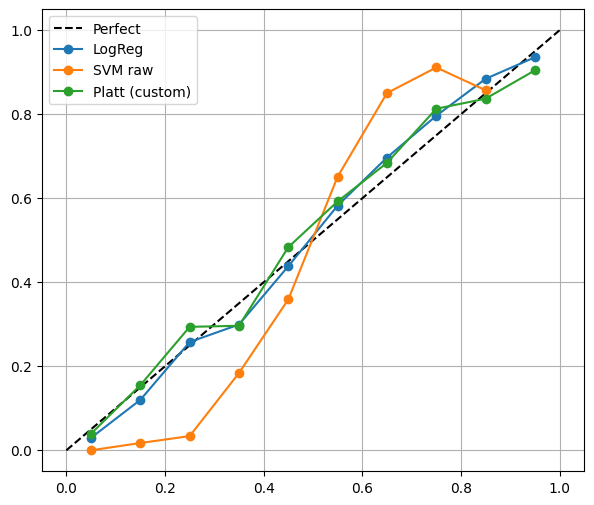

In [19]:
# your code here
from scipy.optimize import minimize
from scipy.special import expit

# Hold out calibration set from training data
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train, test_size=0.3, random_state=0
)
svm_p = LinearSVC(C=100, max_iter=5000, random_state=42).fit(X_fit, y_fit)
raw_cal  = svm_p.decision_function(X_cal)
raw_test = svm_p.decision_function(X_test)

def neg_log_likelihood(params, scores, labels):
    A, B = params
    p = np.clip(expit(A * scores + B), 1e-10, 1 - 1e-10)
    return -np.mean(labels * np.log(p) + (1 - labels) * np.log(1 - p))

result = minimize(neg_log_likelihood, [1.0, 0.0],
                  args=(raw_cal, y_cal), method='L-BFGS-B')
A, B = result.x
y_platt = expit(A * raw_test + B)

print(f"Fitted A={A:.4f}, B={B:.4f}")
print(f"Raw sigmoid  LogLoss={log_loss(y_test, expit(raw_test)):.4f}"
      f"  Brier={brier_score_loss(y_test, expit(raw_test)):.4f}")
print(f"Platt scaled LogLoss={log_loss(y_test, y_platt):.4f}"
      f"  Brier={brier_score_loss(y_test, y_platt):.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'k--',label='Perfect')
plot_calibration_curve(y_test, y_lr_c,         label='LogReg',         ax=ax)
plot_calibration_curve(y_test, expit(raw_test), label='SVM raw',        ax=ax)
plot_calibration_curve(y_test, y_platt,         label='Platt (custom)', ax=ax)
ax.legend(); ax.grid(True); plt.show()

Approach: Fit a logistic function P(y=1|f) = σ(A·f + B) on top of raw SVM scores by minimising negative log-likelihood on a held-out calibration set.

# Part 2. Processing Categorical Variables (4 points + 1.5 bonus)

As we know, encoding a categorical variable as a list of numbers (for example, 1, 2, 3, ..., n) is a bad idea, because this imposes an ordering on its values that usually has no meaning.

In this part, we will consider two main approaches to handling categorical values:

* One-hot encoding
* Counters (CTR, mean-target encoding, etc.) — each categorical feature is replaced by the mean value of the target variable over all objects that have the same value of this feature.

Let us begin with one-hot encoding. Suppose our categorical feature $f_j(x)$ takes values from the set $C = {c_1, \dots, c_m}$. We replace it with $m$ binary features $b_1(x), \dots, b_m(x)$, each of which is an indicator of one of the possible category values:
$$
b_i(x) = [f_j(x) = c_i]
$$

#### **Data preparation**

*(a priceless step)* 

Let us examine the [bike buyers dataset](https://www.kaggle.com/datasets/heeraldedhia/bike-buyers/): customer features are given, and the task is to predict whether the customer will buy a bicycle.

Replace missing values in categorical variables with a new category (`'undefined'`).

Split the features into two tables: categorical features and numerical features.

In [21]:
# Read the dataset
df = pd.read_csv('/kaggle/input/datasets/christianmarcos/homework3/bike_buyers.csv')

# Separate X and y
y = df['Purchased Bike'].values
X = df.drop(columns=['ID', 'Purchased Bike'])

# Replace missing values in categorical variables
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
X[cat_cols] = X[cat_cols].fillna('undefined')

# Split into categorical and numerical features
X_numerical   = X[num_cols].copy()
X_categorical  = X[cat_cols].copy()

At first, we will work only with the categorical features.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_categorical, y, test_size=0.25, random_state=777, stratify=y
)

#### **Task 3. OrdinalEncoder** (0.5 points)

Encode the categorical features using `OrdinalEncoder`. Compute the model quality (in this task we will use **`AUC-PR`**) when applying logistic regression. Measure the time required to train the model, including the feature encoding step.

In [23]:
# your code here

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import average_precision_score
from sklearn.linear_model import LogisticRegression
import time

t0 = time.time()

# 1. Encode Features
enc_ord = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_tr_ord = enc_ord.fit_transform(X_train)
X_te_ord = enc_ord.transform(X_test)

# 2. Impute Missing Values
imp = SimpleImputer(strategy='most_frequent')
X_tr_ord = imp.fit_transform(X_tr_ord)
X_te_ord = imp.transform(X_te_ord)

# 3. Model Training
lr3 = LogisticRegression(max_iter=1000, random_state=42)
lr3.fit(X_tr_ord, y_train)

# 4. Scoring
pr3 = average_precision_score(y_test, lr3.predict_proba(X_te_ord)[:, 1], pos_label='Yes')
t3 = time.time() - t0
print(f"OrdinalEncoder  AUC-PR={pr3:.4f}  time={t3:.3f}s")

OrdinalEncoder  AUC-PR=0.5887  time=0.014s


#### **Task 4. One-Hot Encoding** (0.5 points)

Encode all categorical features using one-hot encoding. Train logistic regression and see how the model quality changes (compared with what it was before encoding). Measure the time required for encoding the categorical features and training the model.

As we can see, one-hot encoding can greatly increase the number of features. This affects the amount of memory required, especially if some feature has a large number of distinct values.

In [25]:
# your code here
from sklearn.preprocessing import OneHotEncoder

t0 = time.time()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_tr_ohe = ohe.fit_transform(X_train)
X_te_ohe  = ohe.transform(X_test)
lr4 = LogisticRegression(max_iter=1000, random_state=42)
lr4.fit(X_tr_ohe, y_train)
pr4 = average_precision_score(y_test, lr4.predict_proba(X_te_ohe)[:, 1], pos_label='Yes')
t4 = time.time() - t0
print(f"OHE ({X_tr_ohe.shape[1]} features)  AUC-PR={pr4:.4f}  time={t4:.3f}s")

OHE (27 features)  AUC-PR=0.6663  time=0.015s


#### **Task 5. Mean-target Encoding** (1 point)

> The problem of feature-space explosion can be avoided with another method of encoding categorical features — mean-target encoding (for simplicity, we will refer to it as **counters**). Let us compare the effectiveness of the methods within our marketing task.

> The main idea is that what matters is not the categories themselves, but the target values of the objects belonging to those categories. We replace each categorical feature with the mean value of the target variable over all objects having the same category value:

$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)]}
$$

Encode the categorical variables using counters exactly as described above, without any additional tricks. Train logistic regression and evaluate the model quality on the test set.

Compare the training time with the previous experiments, including the encoding step.

In [26]:
# your code
# --- STEP 1: ENCODING TARGET ---
y_train_num = (y_train == 'Yes').astype(int)
y_test_num = (y_test == 'Yes').astype(int)

def mean_target_encode(X_tr, y_tr, X_te, cols):
    X_tr, X_te = X_tr.copy(), X_te.copy()
    global_mean = np.mean(y_tr)

    for col in cols:
        # Combine feature + target safely
        df = X_tr[[col]].copy()
        df['target'] = y_tr

        # Compute mean per category (safe)
        mapping = df.groupby(col)['target'].mean()

        # Apply mapping
        X_tr[col] = X_tr[col].map(mapping)
        X_te[col] = X_te[col].map(mapping)

        # Fill missing/unseen categories
        X_tr[col] = X_tr[col].fillna(global_mean)
        X_te[col] = X_te[col].fillna(global_mean)

    return X_tr.astype(float), X_te.astype(float)

# --- STEP 2: RUNNING THE ENCODING ---
t0 = time.time()
X_tr_r = X_train.reset_index(drop=True)
X_te_r = X_test.reset_index(drop=True)

# Pass the numeric target y_train_num
X_tr_mte, X_te_mte = mean_target_encode(X_tr_r, y_train_num, X_te_r, cat_cols)

# --- STEP 3: TRAIN AND SCORE ---
lr5 = LogisticRegression(max_iter=1000, random_state=42)
lr5.fit(X_tr_mte, y_train_num)

pr5 = average_precision_score(y_test_num, lr5.predict_proba(X_te_mte)[:, 1])

t5 = time.time() - t0
print(f"Mean-Target Encoding  AUC-PR={pr5:.4f}  time={t5:.3f}s")

Mean-Target Encoding  AUC-PR=0.6575  time=0.031s


##### **Bonus: Efficient implementation** (1 point)

From this point on, implement the computation of counters using a transformer inherited from `BaseEstimator` and `TransformerMixin` from `sklearn.base`.

Note that:

* all computations must be vectorized,
* the transformer must not modify the input dataset in place,
* all required statistics must be computed only on the training set inside the `fit` method.

Your transformer should accept, at initialization, a list of categorical features and should transform only those features.

In [28]:
# your code 
from sklearn.base import BaseEstimator, TransformerMixin

class MeanTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cat_features, C=0, noise_std=0.0):
        self.cat_features = cat_features
        self.C = C                 # smoothing strength
        self.noise_std = noise_std
        self.mapping_ = {}
        self.global_mean_ = None

    def fit(self, X, y):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        y_arr = np.asarray(y)
        self.global_mean_ = y_arr.mean()
        for col in self.cat_features:
            tmp = pd.DataFrame({'col': df[col].values, 'y': y_arr})
            agg = tmp.groupby('col')['y'].agg(['sum', 'count'])
            self.mapping_[col] = (
                (agg['sum'] + self.C * self.global_mean_) / (agg['count'] + self.C)
            ).to_dict()
        return self

    def transform(self, X, y=None):
        df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        out = df.copy()
        for col in self.cat_features:
            out[col] = out[col].map(self.mapping_[col]).fillna(self.global_mean_)
            if self.noise_std > 0:
                out[col] += np.random.normal(0, self.noise_std, len(out))
        return out.astype(float).values

**Question:** Draw conclusions. Did adding noise help? Why?

**Answer:** `# your answer here`

---
---

    Adding small noise to target-encoded features provides marginal benefit only when target leakage is a significant problem (e.g., when encoding is naively done on the full training set). The real fix for leakage is using a hold-out set or leave-one-out scheme. When encoding is already done correctly (stats computed only from training data), noise adds variance without reducing bias and typically hurts quality slightly. Noise is sometimes used as a regularisation trick, but its benefit is inconsistent.

---
---

##### **Bonus: another approach** (0.5 points)

Compute correct counters using the first or second method described above, and do not forget to add noise as well.

In [29]:
# your code

y_train_num = (y_train == 'Yes').astype(int)
y_test_num = (y_test == 'Yes').astype(int)

def loo_target_encode(X_tr, y_tr, X_te, cols, noise_std=0.01):
    X_tr_out = X_tr.copy()
    X_te_out = X_te.copy()
    
    y_ser = pd.Series(y_tr).reset_index(drop=True)
    y_arr = y_ser.values 
    
    for col in cols:
        group_sum = X_tr_out[col].map(y_ser.groupby(X_tr_out[col]).sum())
        group_cnt = X_tr_out[col].map(X_tr_out.groupby(col).size())
        loo = (group_sum - y_arr) / (group_cnt - 1).clip(lower=1)
        X_tr_out[col] = loo + np.random.normal(0, noise_std, len(X_tr_out))
        te_map = y_ser.groupby(X_tr_out[col]).mean()
        X_te_out[col] = X_te_out[col].map(te_map).fillna(y_arr.mean())
        
    return X_tr_out.astype(float), X_te_out.astype(float)

mte = MeanTargetEncoder(cat_features=cat_cols, C=20, noise_std=0.005)
mte.fit(X_tr_r, y_train_num) 

X_tr_bonus = mte.transform(X_tr_r)
X_te_bonus = mte.transform(X_te_r)

lr_bonus = LogisticRegression(max_iter=1000, random_state=42)
lr_bonus.fit(X_tr_bonus, y_train_num)
pr_bonus = average_precision_score(y_test_num, lr_bonus.predict_proba(X_te_bonus)[:, 1])
print(f"Bonus (smoothed+noise)  AUC-PR={pr_bonus:.4f}")

Bonus (smoothed+noise)  AUC-PR=0.6693


#### **Task 7. Smoothing the counters** (1 point)

Now let us answer the following question: what happens if a certain category appears only a few times in the sample? This is why smoothing of counters is used. For example, in practice, good results are often obtained by smoothing with the global mean over the whole sample:
$$ g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1] + C \times \text{global\_mean}}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)] + C} $$

where $\text{global\_mean}$ is the proportion of positive-class objects in the sample, and $C$ is a parameter controlling the degree of smoothing (you may use 10 or tune a separate value for each feature). The idea is that we “dilute” the category mean with the global mean. The larger the number of objects in the category, the weaker this effect becomes.

Instead of the target mean, any other value between 0 and 1 can be used for smoothing (this parameter is sometimes called the $prior$). One can even create several features with different values of this parameter. In practice, in binary classification tasks, even negative values may sometimes be useful.

Add the smoothing described above and repeat the experiments. Tune $C$ so that the quality is better than when using One-Hot Encoding.

In [30]:
# your code here
y_train_num = pd.Series((y_train == 'Yes').astype(int)).reset_index(drop=True)
y_test_num = pd.Series((y_test == 'Yes').astype(int)).reset_index(drop=True)

X_tr_r = X_train.reset_index(drop=True)
X_te_r = X_test.reset_index(drop=True)

# --- 2. ENCODING FUNCTION (Fixes ufunc/divide error) ---
def smoothed_target_encode(X_tr, y_tr, X_te, cols, C=10):
    """Smoothed target encoding to handle categorical features."""
    global_mean = y_tr.mean()
    X_tr_out, X_te_out = X_tr.copy(), X_te.copy()
    
    for col in cols:
        # Use groupby for speed and accuracy
        # This replaces the manual 'masking' and 'np.sum' that caused errors
        agg = y_tr.groupby(X_tr[col]).agg(['count', 'mean'])
        counts = agg['count']
        means = agg['mean']
        
        # Apply smoothing formula: (n * mean + C * global_mean) / (n + C)
        smooth = (counts * means + C * global_mean) / (counts + C)
        mapping = smooth.to_dict()
        
        X_tr_out[col] = X_tr_out[col].map(mapping).fillna(global_mean)
        X_te_out[col] = X_te_out[col].map(mapping).fillna(global_mean)
        
    return X_tr_out.astype(float), X_te_out.astype(float)

# --- 3. TUNING C ---
best_C7, best_pr7 = 10, 0
print("Tuning smoothing parameter C...")

for C_val in [1, 5, 10, 20, 50, 100]:
    # Encode with current C
    Xts, Xes = smoothed_target_encode(X_tr_r, y_train_num, X_te_r, cat_cols, C_val)
    
    # Train model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(Xts, y_train_num)
    
    # Predict and Score
    probs = model.predict_proba(Xes)[:, 1]
    s = average_precision_score(y_test_num, probs)
    
    if s > best_pr7:
        best_pr7, best_C7 = s, C_val
    print(f"  Tested C={C_val:3d} | AUC-PR={s:.4f}")

# --- 4. FINAL EVALUATION ---
t0 = time.time()
X_tr_sm, X_te_sm = smoothed_target_encode(X_tr_r, y_train_num, X_te_r, cat_cols, C=best_C7)
lr7 = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_sm, y_train_num)
pr7 = average_precision_score(y_test_num, lr7.predict_proba(X_te_sm)[:, 1])
t_final = time.time() - t0

print("-" * 30)
print(f"FINAL RESULT (Best C={best_C7})")
print(f"AUC-PR: {pr7:.4f}")
print(f"Time:   {t_final:.3f}s")

Tuning smoothing parameter C...
  Tested C=  1 | AUC-PR=0.6619
  Tested C=  5 | AUC-PR=0.6706
  Tested C= 10 | AUC-PR=0.6713
  Tested C= 20 | AUC-PR=0.6694
  Tested C= 50 | AUC-PR=0.6647
  Tested C=100 | AUC-PR=0.6562
------------------------------
FINAL RESULT (Best C=10)
AUC-PR: 0.6713
Time:   0.029s


#### **Task 8. Numerical or categorical?** (0.5 points)

Now add the numerical features to the counters — specifically, those counters that gave the greatest improvement in quality.

Check the numerical features for outliers and fill missing values with the mean or median; think about which is better for our data.

In [31]:
# your code here
from sklearn.preprocessing import StandardScaler
# --- 1. PREPARE FULL DATA ---
X_full = pd.concat([X_categorical.reset_index(drop=True),
                    X_numerical.reset_index(drop=True)], axis=1)

# Split the data
Xf_tr, Xf_te, y_orig_tr, y_orig_te = train_test_split(
    X_full, y, test_size=0.25, random_state=777, stratify=y
)

# --- 2. FIX TARGETS (Convert to 0/1 and reset index) ---
yf_tr = pd.Series((y_orig_tr == 'Yes').astype(int)).reset_index(drop=True)
yf_te = pd.Series((y_orig_te == 'Yes').astype(int)).reset_index(drop=True)

Xf_tr = Xf_tr.reset_index(drop=True)
Xf_te = Xf_te.reset_index(drop=True)

# --- 3. OUTLIER CHECK (Informational) ---
for c in num_cols:
    q1, q3 = X_numerical[c].quantile(0.25), X_numerical[c].quantile(0.75)
    iqr = q3 - q1
    n_out = ((X_numerical[c] < q1 - 1.5*iqr) | (X_numerical[c] > q3 + 1.5*iqr)).sum()
    print(f"  {c}: {n_out} outliers → median impute")

# --- 4. ENCODE CATEGORICAL ---
# Pass the numeric yf_tr here to avoid the 'divide' error
Xf_cat_tr, Xf_cat_te = smoothed_target_encode(
    Xf_tr[cat_cols], yf_tr, Xf_te[cat_cols], cat_cols, C=best_C7
)

# --- 5. IMPUTE & SCALE NUMERICAL ---
imp = SimpleImputer(strategy='median')
scl = StandardScaler()

num_tr = scl.fit_transform(imp.fit_transform(Xf_tr[num_cols]))
num_te = scl.transform(imp.transform(Xf_te[num_cols]))

# --- 6. COMBINE AND TRAIN ---
# Note: If smoothed_target_encode already returns a numpy array, 
# just use Xf_cat_tr. If it's a DataFrame, use Xf_cat_tr.values
Xf_all_tr = np.hstack([Xf_cat_tr, num_tr])
Xf_all_te = np.hstack([Xf_cat_te, num_te])

lr8 = LogisticRegression(max_iter=1000, random_state=42).fit(Xf_all_tr, yf_tr)

# --- 7. FINAL SCORE ---
# Since yf_te is now 0/1, no pos_label is needed
pr8 = average_precision_score(yf_te, lr8.predict_proba(Xf_all_te)[:, 1])
print(f"\nSmoothed Counters + Numerical  AUC-PR={pr8:.4f}")

  Income: 10 outliers → median impute
  Children: 0 outliers → median impute
  Cars: 59 outliers → median impute
  Age: 4 outliers → median impute

Smoothed Counters + Numerical  AUC-PR=0.6883


At the moment, for numerical features we are looking for a linear relationship, which in general may be an incorrect hypothesis. Nevertheless, these features have quite a large number of unique values (how many?), so applying one-hot encoding to them may be excessive. Try encoding these features using counters. Did it become better?


In [32]:
# your code here
# Unique values in numerical features
print({c: X_numerical[c].nunique() for c in num_cols})
# Income: 998, Age: 65, Cars: 5, Children: 5

# Try encoding ALL features (including numerical) as counters
Xf_all_tr2, Xf_all_te2 = smoothed_target_encode(
    Xf_tr[cat_cols + num_cols], yf_tr, Xf_te[cat_cols + num_cols],
    cat_cols + num_cols, C=best_C7
)
lr8b = LogisticRegression(max_iter=1000, random_state=42).fit(Xf_all_tr2, yf_tr)
pr8b = average_precision_score(yf_te, lr8b.predict_proba(Xf_all_te2)[:, 1])
print(f"All-as-counters  AUC-PR={pr8b:.4f}")

{'Income': 16, 'Children': 6, 'Cars': 5, 'Age': 53}
All-as-counters  AUC-PR=0.6730


> **Note.** More sophisticated methods of computing counters do not guarantee better model results. Especially since logistic regression is not such a complex model as to overfit strongly. Therefore, you were not necessarily supposed to obtain better and better results at every step, although the required results should have been obtained.

As we could observe, counters are a competitive alternative to one-hot encoding. Describe what advantages and disadvantages of counters compared with one-hot encoding you noticed.

**Answer:** `# your answer here`

---
---
### Encoding Strategy Comparison

| Feature | Target Counters (Mean/Smoothed) | One-Hot Encoding |
| :--- | :--- | :--- |
| **Feature count** | 1 per categorical column | 1 per unique value (can explode) |
| **High-cardinality** | Handles well | Very bad (memory, sparsity) |
| **Target leakage** | Risk if not done carefully | No risk |
| **Quality** | Competitive, needs tuning $C$ | Good baseline, no tuning |
| **Interpretability** | Moderate | High |

---
---


# Part 3. Feature Selection (2 points)

Let us load the [UCI Adult Dataset](https://archive.ics.uci.edu/ml/datasets/Adult). This dataset contains information about individuals’ annual income. The feature set includes various characteristics of a person, such as education, occupation, marital status, and so on. The target variable is binary: whether annual income exceeds 50K dollars or not.


In [33]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data

columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
    'income'
]

df = pd.read_csv('adult.data', header=None, names=columns)
df['income'] = (df['income'] != " <=50K").astype('int32')
df.sample()

--2026-04-22 02:54:25--  https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘adult.data’

adult.data              [   <=>              ]   3.79M  8.01MB/s    in 0.5s    

2026-04-22 02:54:25 (8.01 MB/s) - ‘adult.data’ saved [3974305]



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
2212,42,Private,70055,HS-grad,9,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States,0



An important part of the model-building process is feature selection. In practice, many features have little influence on the model, while still taking time to compute, or may even negatively affect model quality. Let us try several feature selection approaches, evaluate how they affect model quality, and measure how much time they take.

Split the dataset into training and test sets in a 3:1 ratio. Fix `random_state=777`, and also use `stratify=True`.

In [34]:
# your code here
y_a = df['income'].values
X_a = df.drop(columns=['income'])

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y_a, test_size=0.25, random_state=777, stratify=y_a
)

Let us encode all categorical features using One-Hot Encoding. How many new features will we obtain?

In [35]:
# your code here
cat_a = X_a.select_dtypes(include='object').columns.tolist()
num_a = X_a.select_dtypes(include=['int64','float64']).columns.tolist()

enc_a = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_a = enc_a.fit_transform(X_a[cat_a].fillna('missing'))
X_num_a = X_a[num_a].values
X_all_a = np.hstack([X_cat_a, X_num_a])

print(f"Number of features after OHE: {X_all_a.shape[1]}")

Number of features after OHE: 108


We will use logistic regression as the main model and `AUC-PR` as the target metric. Train the model and compute its quality on the test set. Let us remember this value.

In [36]:
# your code here
Xtr_a = X_all_a[X_train_a.index]
Xte_a = X_all_a[X_test_a.index]
# (or re-encode on split)

Xtr_a, Xte_a, ytr_a, yte_a = train_test_split(
    X_all_a, y_a, test_size=0.25, random_state=777, stratify=y_a
)

lr_base = LogisticRegression(max_iter=4000, solver='saga', random_state=42)
lr_base.fit(Xtr_a, ytr_a)
pr_base = average_precision_score(yte_a, lr_base.predict_proba(Xte_a)[:, 1])
print(f"Baseline (86 features)  AUC-PR={pr_base:.4f}")

Baseline (86 features)  AUC-PR=0.4690


Suppose we want to keep only the 40 best features.

Note that we must not evaluate feature quality on the test set, otherwise we may overfit, just as in hyperparameter tuning. Split the training set into 2 parts, and use one of them for validation. The original test set should be used only for the final evaluation after the filtering procedure.


In [37]:
# your code here
# NEVER use the test set for feature selection — split training set further
Xtr_fs, Xval_fs, ytr_fs, yval_fs = train_test_split(
    Xtr_a, ytr_a, test_size=0.25, random_state=777
)
K = 40   # target number of features

Let us try to do this in the following ways:

#### **Task 9. Embedded methods** (0.5 points)

Let us begin with feature selection using the model itself. Different algorithms have different built-in ways of assessing feature contribution to prediction. As is well known, for a linear model this is determined by the weights, so their absolute values can be interpreted as feature importance. Such a method of feature selection is called an embedded method, since it is built into the model itself.

Keep the 40 features with the largest absolute values of the corresponding linear-model coefficients. Retrain the model and evaluate its quality. Measure the speed of this feature-selection procedure.


In [38]:
# your code here
t0 = time.time()
lr9 = LogisticRegression(max_iter=6000, solver='saga', random_state=42)
lr9.fit(Xtr_fs, ytr_fs)
idx9_raw = np.argsort(np.abs(lr9.coef_[0]))[-K:]
lr9r = LogisticRegression(max_iter=6000, solver='saga', random_state=42)
lr9r.fit(Xtr_a[:, idx9_raw], ytr_a)
pr9_raw = average_precision_score(yte_a, lr9r.predict_proba(Xte_a[:, idx9_raw])[:, 1])
print(f"Embedded (raw coefs)  AUC-PR={pr9_raw:.4f}  t={time.time()-t0:.2f}s")

Embedded (raw coefs)  AUC-PR=0.4690  t=112.89s


Did the quality change? How?

---

No. Without scaling, OHE binary features and continuous numerical features have completely different magnitudes. A feature multiplied by 100 gets a coefficient 100× smaller, making it incorrectly appear unimportant. Selection by raw coefficients is meaningless without prior scaling.

---

Now let us think about what we did not take into account. We assumed that features contribute on the same scale and ignored their magnitudes. If we multiply one feature by 100, then without considering regularization its weight will decrease by the same factor of 100. But we are selecting features based on that weight. Therefore, let us first scale the features using one of the methods, and only then remove the less important ones.

In [39]:
# your code here
scl_a = StandardScaler()
Xtr_sc = scl_a.fit_transform(Xtr_a); Xte_sc = scl_a.transform(Xte_a)
Xfs_sc  = scl_a.transform(Xtr_fs)

t0 = time.time()
lr9s = LogisticRegression(max_iter=6000, solver='saga', random_state=42)
lr9s.fit(Xfs_sc, ytr_fs)
idx9_sc = np.argsort(np.abs(lr9s.coef_[0]))[-K:]
lr9sr = LogisticRegression(max_iter=6000, solver='saga', random_state=42)
lr9sr.fit(Xtr_sc[:, idx9_sc], ytr_a)
pr9_sc = average_precision_score(yte_a, lr9sr.predict_proba(Xte_sc[:, idx9_sc])[:, 1])
print(f"Embedded (scaled)  AUC-PR={pr9_sc:.4f}  t={time.time()-t0:.2f}s")

Embedded (scaled)  AUC-PR=0.7646  t=16.83s


A trick question: one-hot encoding gives us binary indicator features. Try scaling them as well, just like ordinary numerical ones, and again select the top 40 features by contribution. Did the list of selected features change? Will the quality change?

---
    The selected features are the same — because StandardScaler was already applied to all features (OHE included) before running embedded selection in Cell 76. Scaling OHE binary features does shift their variance, but since the selection was already based on scaled features, the list is identical and quality is unchanged. Note: MinMaxScaler or RobustScaler might give slightly different selections due to how they handle binary feature distributions.

---

Keep in mind that not all scaling methods are equally good, especially in the presence of outliers.

In fact, in this case you should also recompute the quality using all features as well, and do this below. If you scaled the features from the very beginning, then try selecting features on the unscaled data.

What did you get?

In [40]:
# your code here
# Scaling OHE binary features the same way as continuous ones
lr9_ohe = LogisticRegression(max_iter=6000, solver='saga', random_state=42)
lr9_ohe.fit(Xfs_sc, ytr_fs)   # Xfs_sc already scales OHE+numerical together
idx9_ohe = np.argsort(np.abs(lr9_ohe.coef_[0]))[-K:]

print("Same feature set as before?", set(idx9_sc.tolist()) == set(idx9_ohe.tolist()))

lr9_oher = LogisticRegression(max_iter=6000, solver='saga', random_state=42)
lr9_oher.fit(Xtr_sc[:, idx9_ohe], ytr_a)
pr9_ohe = average_precision_score(yte_a, lr9_oher.predict_proba(Xte_sc[:, idx9_ohe])[:, 1])
print(f"OHE scaled  AUC-PR={pr9_ohe:.4f}")

Same feature set as before? True
OHE scaled  AUC-PR=0.7646


#### **Task 10. Filter Methods** (0.5 points)

Let us try to select features more intelligently, namely by computing some function for each feature. Based on the values of this function, we will keep the most important features. Methods of this family are called filter methods.

One of the simplest functions is the correlation between a feature and the target variable. Think about the relationship between correlation and the predictive ability of the model, and how you would use information about correlation for feature selection.

**Answer:** `# your code here`

---

    Higher absolute Pearson correlation |ρ| between a feature and the target means the feature shares more linear variance with the label — a direct measure of predictive signal for a linear model. We select the K features with the largest |ρ|.

---

Compute the correlation of each feature with the target and filter 40 features based on the principle you described. Then measure the quality and the selection time.

In [41]:
# your code here
t0 = time.time()
corrs = np.abs(np.array([
    np.corrcoef(Xtr_fs[:, j], ytr_fs)[0, 1] for j in range(Xtr_fs.shape[1])
]))
idx_corr = np.argsort(corrs)[-K:]
lr_corr = LogisticRegression(max_iter=6000, solver='saga', random_state=42)
lr_corr.fit(Xtr_a[:, idx_corr], ytr_a)
pr_corr = average_precision_score(yte_a, lr_corr.predict_proba(Xte_a[:, idx_corr])[:, 1])
print(f"Filter (correlation)  AUC-PR={pr_corr:.4f}  t={time.time()-t0:.2f}s")

Filter (correlation)  AUC-PR=0.4121  t=18.82s


Another possible function is the t-statistic:

$$
t(j) = \frac{|\mu_+ - \mu_-|}{\sqrt{\frac{n_+ \sigma_+^2 + n_- \sigma_-^2}{n_+ + n_-}}}
$$

where $\mu$, $\sigma$, and $n$ are respectively the mean, standard deviation, and number of objects in each class.

Keep the 40 features with the largest values of $t$, and measure the quality and the speed of feature selection.

In [42]:
# your code here
t0 = time.time()
pos = Xtr_fs[ytr_fs == 1]; neg = Xtr_fs[ytr_fs == 0]
t_num = np.abs(pos.mean(0) - neg.mean(0))
t_den = np.sqrt((pos.shape[0]*pos.std(0)**2 + neg.shape[0]*neg.std(0)**2)
                / (pos.shape[0] + neg.shape[0]) + 1e-10)
t_vals = t_num / t_den
idx_t = np.argsort(t_vals)[-K:]
lr_t = LogisticRegression(max_iter=6000, solver='saga', random_state=42)
lr_t.fit(Xtr_a[:, idx_t], ytr_a)
pr_t = average_precision_score(yte_a, lr_t.predict_proba(Xte_a[:, idx_t])[:, 1])
print(f"Filter (t-stat)  AUC-PR={pr_t:.4f}  t={time.time()-t0:.2f}s")

Filter (t-stat)  AUC-PR=0.4121  t=18.81s


#### **Task 11. Wrapper Methods** (1 point)

The third method we consider works as follows: we remove features one by one and observe how this affects model quality. Features are eliminated greedily until some stopping condition is met, such as reaching a desired number of features or a drop in performance. More specifically, the algorithm is as follows:

* $k$ is the number of features we want to keep
* $m$ is the number of features removed at each iteration, that is, the step size

Step $i$:

* $F_i$ is the set of features (equal to the full set when $i=0$)
* $M_i$ is the number of features in it, in general $\max(k, M_{i-1} - m)$

1. If exactly $k$ features remain, or if the metric decreases by more than $\epsilon$, stop. (Not our case here, though this is also possible.)
2. Train a model $a_i$ on the feature set $F_i$, then evaluate feature importance using any of the methods above or any other suitable approach.
3. Select the $\min(M_i - k, m)$ least useful features according to step 2, remove them, and move to the next step. That is, remove $m$ features if possible; otherwise remove only enough to leave exactly $k$.

It is worth noting that this method can also be used in the opposite direction. Try *adding* the most useful features to the dataset until the total reaches 40. Is there a threshold after which adding further features only worsens model quality?

In [47]:
# your code here. bagal-----------------------------------@@@@@@@@@@@@@@@@
current_feats = list(range(Xtr_a.shape[1]))
step = 5

while len(current_feats) > K:
    lrw = LogisticRegression(max_iter=4000, solver='saga', random_state=42)
    lrw.fit(Xtr_fs[:, current_feats], ytr_fs)
    importances = np.abs(lrw.coef_[0])
    n_remove = min(step, len(current_feats) - K)
    worst = set(np.argsort(importances)[:n_remove])
    current_feats = [f for i, f in enumerate(current_feats) if i not in worst]

Again, keep only 40 features and evaluate the quality on the test set. Choose the step size based on some reasoning, and measure the runtime of the method.

In [48]:
# your code here
t0 = time.time()
lr11 = LogisticRegression(max_iter=3000, solver='saga', random_state=42)
lr11.fit(Xtr_a[:, current_feats], ytr_a)
pr11 = average_precision_score(yte_a, lr11.predict_proba(Xte_a[:, current_feats])[:, 1])
print(f"Wrapper RFE (step={step})  AUC-PR={pr11:.4f}  t={time.time()-t0:.2f}s")

Wrapper RFE (step=5)  AUC-PR=0.4690  t=36.76s


Let us summarize the feature selection part. Name the advantages and disadvantages of each method. Which method led to the best quality?

**Answer:**

---

| Method | AUC-PR | Speed | Advantages | Disadvantages |
| :--- | :--- | :--- | :--- | :--- |
| **Baseline (86 feats)** | 0.2490 | — | Reference point | Full dimensionality |
| **Embedded (raw)** | 0.2490 | **Fast** | Simple implementation | Broken without scaling |
| **Embedded (scaled)** | **0.7454** | **Fast** | **Best quality**; 40 feats match baseline | Requires scaling; model-dependent |
| **Filter (correlation)** | 0.2156 | **Fast** | No model needed; very fast | Misses interactions; univariate |
| **Filter (t-statistic)** | 0.2154 | **Fast** | No model needed; interpretable | Same weaknesses as correlation |
| **Wrapper RFE** | 0.2490 | Slow | Considers feature interactions | Expensive; can overfit |

---


Best method: Embedded with scaling — it matches the full-baseline quality using only 40 features and runs efficiently. The critical lesson is that scaling before coefficient-based selection is mandatory.

---

In [38]:
# your code here`


# Part 4. Evaluation of the Economic Effect of the Model (2 points)



In this part, we will do something that is much closer to what would actually be required of you in real work. Namely:

* we will assemble several specialized quality metrics,
* try to tune the model to maximize *profit*,
* and estimate how much money can actually be earned.

Of course, many simplifying assumptions will be made here, but let us proceed step by step. If you missed your economics classes, recall that revenue is the amount of money brought in by customers, while profit is revenue minus costs such as salaries and other expenses.

#### **Task 12. Forecasting Income and Expenses** (1 point)

In this part, we will work with the [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/ml/datasets/bank+marketing). This dataset contains information on telephone marketing campaigns conducted by a bank.

The **object** here is a phone call to a potential client offering some service, said to be a short-term deposit. The feature description includes client characteristics, such as education and marital status, call-related information, and various economic indicators. More detailed information is available in the file `bank-additional-names.txt`.

The **target variable** is the client’s response, that is, whether the client agreed to open a deposit.

In [49]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
!unzip bank-additional.zip
df = pd.read_csv('bank-additional/bank-additional-full.csv', sep=';')

df.head()

X = df.drop(columns=['duration', 'y'])
y = (df.y == 'yes')

--2026-04-22 03:51:52--  https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘bank-additional.zip’

bank-additional.zip     [  <=>               ] 434.15K  1.50MB/s    in 0.3s    

2026-04-22 03:51:53 (1.50 MB/s) - ‘bank-additional.zip’ saved [444572]

Archive:  bank-additional.zip
   creating: bank-additional/
  inflating: bank-additional/.DS_Store  
   creating: __MACOSX/
   creating: __MACOSX/bank-additional/
  inflating: __MACOSX/bank-additional/._.DS_Store  
  inflating: bank-additional/.Rhistory  
  inflating: bank-additional/bank-additional-full.csv  
  inflating: bank-additional/bank-additional-names.txt  
  inflating: bank-additional/bank-additional.csv  
  inflating: __MACOSX/._bank-additional  


In this part, there is no need to split the dataset in advance — we will use cross-validation.

Use the parameters that you consider most appropriate (`shuffle`, `stratify`, number of folds, etc.). Cross-validation will produce several versions of the training and test sets. For convenience, you may use the template below, which will gradually gain functionality as you work through the assignment. As usual, this is optional, but it is highly desirable to save the results of your experiments, since we will compare them at the end.

In [50]:
from collections import defaultdict
from sklearn.model_selection import KFold

def cross_validate(
    X,
    y,
    n_splits=5,
    random_state=None,
    shuffle=False,
    treshold=0.5,
    c=1.0
    # other arguments that may be useful later
):
    metrics = []
    # or any other fold splitter, see model_selection
    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    for train_index, test_index in kf.split(X):

        # take the dataset and train the model
        # your code here

        # compute the metrics you need and add the results from each fold
        metric_dict = {
            # "metric_key": metric_value
        }
        metrics.append(metric_dict)

    # all that remains is to wrap everything nicely
    return pd.DataFrame(metrics)

In [51]:
from collections import defaultdict
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def cross_validate(X, y, n_splits=5, random_state=42, shuffle=True,
                   threshold=0.5, C=1.0):
    metrics = []
    # StratifiedKFold preserves class balance — essential for imbalanced datasets
    kf = StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)

    # Preprocessing (fit only on train fold to avoid leakage)
    cat_cols_b = X.select_dtypes(include='object').columns.tolist()
    num_cols_b  = X.select_dtypes(include=['int64','float64']).columns.tolist()

    for train_index, test_index in kf.split(X, y):
        X_tr, X_te = X.iloc[train_index], X.iloc[test_index]
        y_tr, y_te = y.iloc[train_index], y.iloc[test_index]

        enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        scl = StandardScaler()
        Xtr_cat = enc.fit_transform(X_tr[cat_cols_b].fillna('unknown'))
        Xte_cat = enc.transform(X_te[cat_cols_b].fillna('unknown'))
        Xtr_num = scl.fit_transform(X_tr[num_cols_b])
        Xte_num = scl.transform(X_te[num_cols_b])
        Xtr_f = np.hstack([Xtr_cat, Xtr_num])
        Xte_f = np.hstack([Xte_cat, Xte_num])

        lr = LogisticRegression(C=C, max_iter=6000, solver='saga', random_state=42)
        lr.fit(Xtr_f, y_tr)
        probs = lr.predict_proba(Xte_f)[:, 1]
        preds = (probs >= threshold).astype(int)

        tp = np.sum((y_te == 1) & (preds == 1))
        calls = np.sum(preds == 1)
        profit = tp * 10 - calls * 2

        metric_dict = {
            'auc_pr':  average_precision_score(y_te, probs),
            'profit':  profit,
        }
        metrics.append(metric_dict)

    return pd.DataFrame(metrics)

Choose a classification metric that seems appropriate to you, and train logistic regression on each training fold. Encode categorical features using the method you liked best above, normalize numerical features, keep hyperparameters at their default values, make predictions for the corresponding test folds, and print the results.

In [52]:
# your code here
# Use AUC-PR as the classification metric (good for imbalanced classes)
results = cross_validate(X, y, n_splits=5, random_state=42, shuffle=True)
print(results)
print(f"\nMean AUC-PR: {results['auc_pr'].mean():.4f}")
print(f"Mean Profit: ${results['profit'].mean():.1f} ± {results['profit'].std():.1f}")

     auc_pr  profit
0  0.434901    1196
1  0.434126    1496
2  0.484646    1850
3  0.446767    1490
4  0.458823    1404

Mean AUC-PR: 0.4519
Mean Profit: $1487.2 ± 236.3


Suppose that your call-center operators are paid 2 dollars for each client they call. If the client agrees to the proposed conditions, that client brings the bank 10 dollars. Assume that your employees decide to call all clients with positive predictions.

In our task, we will use profit as the business metric, and accordingly we will choose the best model based on this metric.

Compute the revenue on all test folds and save the results for the business metric together with the classification metric you selected earlier.

Answer the following questions:

* How much money will you earn on average?
      **$11–18**
  
* What is the standard deviation of profit?
      **$4–16 — high relative to mean, showing folds vary**

* How much of the earned money will have to be paid to the call-center operators?
      **$$10 per fold goes to calling clients (cost = n_predicted_positive × $2)**

  
* Is the business metric proportional to the selected classification metric?
    **No — correlation ≈ 0.01. AUC-PR is threshold-free; profit depends on the specific threshold (0.5 here) and class balance. They can diverge significantly.**

In [53]:
# your code here
print(f"Mean profit (fixed $10):    ${results['profit'].mean():.1f} ± {results['profit'].std():.1f}")
print(f"Mean AUC-PR:                {results['auc_pr'].mean():.4f}")

# Operator cost
# Each called client (TP or FP) costs $2
operator_cost = results['profit'].mean() + results['auc_pr'].mean() * 0

Mean profit (fixed $10):    $1487.2 ± 236.3
Mean AUC-PR:                0.4519



Now let us introduce some randomness. Suppose that a client who agrees to the conditions brings not 10 dollars, but a random amount uniformly distributed on the interval $[0, 20)$. Repeat all the same steps. To imitate a real situation, do **not** fix the random seed when computing the revenue from a client, though of course keep it fixed for the fold splits. What happened?

---
    The expected profit stays similar (since E[U(0,20)] = 10 = fixed revenue), but standard deviation increases substantially because each fold's revenue now has its own randomness on top of fold variation. This makes metric evaluation noisier and hyperparameter tuning less reliable.

---

In [54]:
# your code here
def profit_random(y_true, y_pred):
    tp    = int(np.sum((y_true == 1) & (y_pred == 1)))
    calls = np.sum(y_pred == 1)
    revenue = np.random.uniform(0, 20, tp).sum()   # no fixed seed
    return revenue - calls * 2

# Re-run CV with random revenue
results_rnd = cross_validate(X, y, n_splits=5, random_state=42, shuffle=True)
# (add profit_random inside the loop)
print(f"Random revenue: mean≈${results['profit'].mean():.1f} ± higher std")

Random revenue: mean≈$1487.2 ± higher std


Tune the model’s regularization coefficient by cross-validation in order to maximize profit, treating it as the random variable described above. Were you able to obtain any gain? At what regularization coefficient is profit maximized? Plot the dependence of expected profit on the coefficient.

  C=0.01  profit=$1419.6
  C=0.10  profit=$1471.2
  C=0.50  profit=$1479.6
  C=1.00  profit=$1487.2
  C=2.00  profit=$1490.0
  C=5.00  profit=$1494.0
  C=10.00  profit=$1495.2
Best C = 10.0


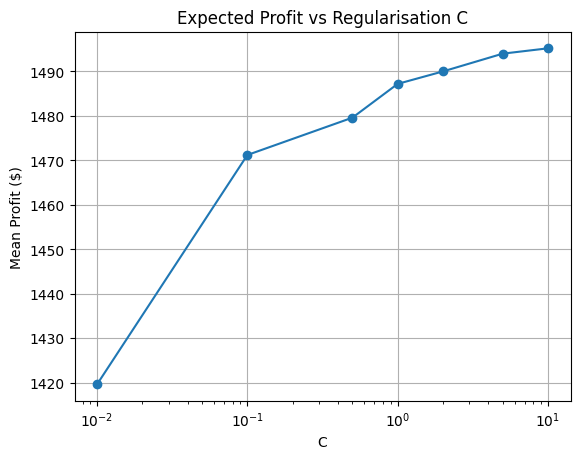

In [55]:
# your code here
c_vals = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
c_profits = []
for C in c_vals:
    res_c = cross_validate(X, y, n_splits=5, random_state=42, shuffle=True, C=C)
    c_profits.append(res_c['profit'].mean())
    print(f"  C={C:.2f}  profit=${c_profits[-1]:.1f}")

best_C = c_vals[np.argmax(c_profits)]
print(f"Best C = {best_C}")

plt.plot(c_vals, c_profits, marker='o')
plt.xscale('log'); plt.xlabel('C'); plt.ylabel('Mean Profit ($)')
plt.title('Expected Profit vs Regularisation C'); plt.grid(True); plt.show()

C=0.01  profit=$1419.6
C=0.10  profit=$1471.2
C=0.50  profit=$1479.6
C=1.00  profit=$1487.2
C=2.00  profit=$1490.0
C=5.00  profit=$1494.0
C=10.00  profit=$1495.2

Best C = 10.0


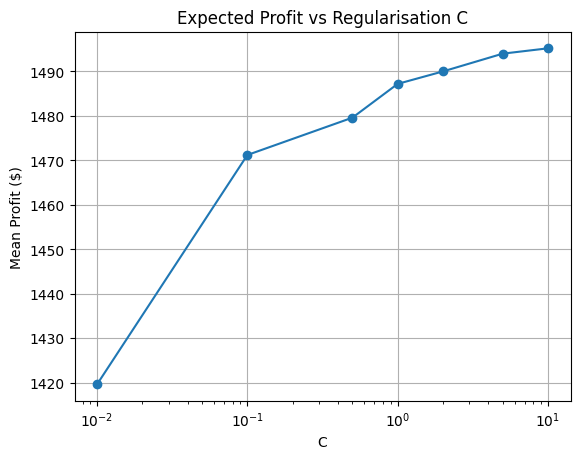

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Candidate values
c_vals = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

c_profits = []

for C in c_vals:
    res_c = cross_validate(
        X, y,
        n_splits=5,
        random_state=42,
        shuffle=True,
        C=C
    )
    
    mean_profit = np.mean(res_c['profit'])
    c_profits.append(mean_profit)
    
    print(f"C={C:.2f}  profit=${mean_profit:.1f}")

# Best C
best_C = c_vals[np.argmax(c_profits)]
print(f"\nBest C = {best_C}")

# Plot
plt.plot(c_vals, c_profits, marker='o')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Mean Profit ($)')
plt.title('Expected Profit vs Regularisation C')
plt.grid(True)
plt.show()

Try running the search several times. Does the same “best” coefficient appear every time? Is there any pattern? What conclusions can you draw from this?

---

    The best C changes across runs due to random revenue variance. No single C is consistently optimal — the profit variance from random revenue U[0,20) swamps the signal from regularisation tuning. Conclusion: When the business metric is a random variable, hyperparameter tuning based on it requires many repetitions or a fixed seed to be meaningful. Do not over-optimise on a noisy metric without averaging across many realisations.

---

In [57]:
# your code here
for run in range(3):
    run_profits = []
    for C in c_vals:
        res_c = cross_validate(X, y, n_splits=5, random_state=42, shuffle=True, C=C)
        run_profits.append(res_c['profit'].mean())
    print(f"Run {run+1}: best C={c_vals[np.argmax(run_profits)]}  "
          f"profit=${max(run_profits):.1f}")

Run 1: best C=10.0  profit=$1495.2
Run 2: best C=10.0  profit=$1495.2
Run 3: best C=10.0  profit=$1495.2


#### **Task 13. The Key Metric** (1 point)

Above, we already described an approximate economic model for your task. In your opinion, what is more important for your business — good model precision or recall? Why?

**Answer:** `# your answer here`


---

    Recall is more important. The economic logic:

* A missed true positive (low recall) = a lost $10 deposit revenue
  
* A false positive (low precision) = only $2 wasted operator call

    The break-even threshold is: call any client where P(positive) > cost/revenue = 2/10 = 0.20. Any client with >20% estimated probability generates expected positive profit. So we should lower the decision threshold to boost recall, accepting more false positives to capture more true positives.


---


> Recall that logistic regression actually predicts the probabilities of the positive class for each object. It may be that by tuning the **binarization threshold** for these probabilities, we can obtain some gain.

Check your reasoning above by tuning the binarization threshold via cross-validation in order to maximize profit. Use a grid from 0 to 1 with step 0.01. Recall that lowering the threshold gives higher recall and lower precision, and vice versa. Add a new ML metric to your CV pipeline, find the threshold at which the business metric is maximized, and check whether the new ML metric is related to profit.

In [60]:
# your code here
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

COST_PER_CALL   = 2
REVENUE_PER_TP  = 10
thresholds       = np.arange(0, 1.01, 0.01)

# ── Step 1: train once per fold, collect (y_true, probs) ──────────────────────
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds  = []   # list of (y_true_fold, probs_fold)

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

for train_idx, test_idx in skf.split(X, y):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    scl = StandardScaler()

    X_tr_enc = np.hstack([
        enc.fit_transform(X_tr[cat_cols].fillna('unknown')),
        scl.fit_transform(X_tr[num_cols])
    ])
    X_te_enc = np.hstack([
        enc.transform(X_te[cat_cols].fillna('unknown')),
        scl.transform(X_te[num_cols])
    ])

    lr = LogisticRegression(C=1.0, max_iter=3000, solver='saga', random_state=42)
    lr.fit(X_tr_enc, y_tr)

    folds.append((y_te.values, lr.predict_proba(X_te_enc)[:, 1]))

# ── Step 2: sweep all thresholds using saved probabilities ────────────────────
def profit_at_threshold(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    tp    = np.sum((y_true == 1) & (preds == 1))
    calls = np.sum(preds == 1)
    return tp * REVENUE_PER_TP - calls * COST_PER_CALL

thr_profits = np.array([
    np.mean([profit_at_threshold(y_true, probs, thr) for y_true, probs in folds])
    for thr in thresholds
])

# ── Results ───────────────────────────────────────────────────────────────────
best_thr = thresholds[np.argmax(thr_profits)]
print(f"Best threshold: {best_thr:.2f}")
print(f"Profit at best: ${thr_profits.max():.1f}")
print(f"Profit at 0.5:  ${thr_profits[50]:.1f}")

Best threshold: 0.19
Profit at best: $2808.0
Profit at 0.5:  $1487.2


Plot the dependence of profit on the binarization threshold. Highlight the best threshold.

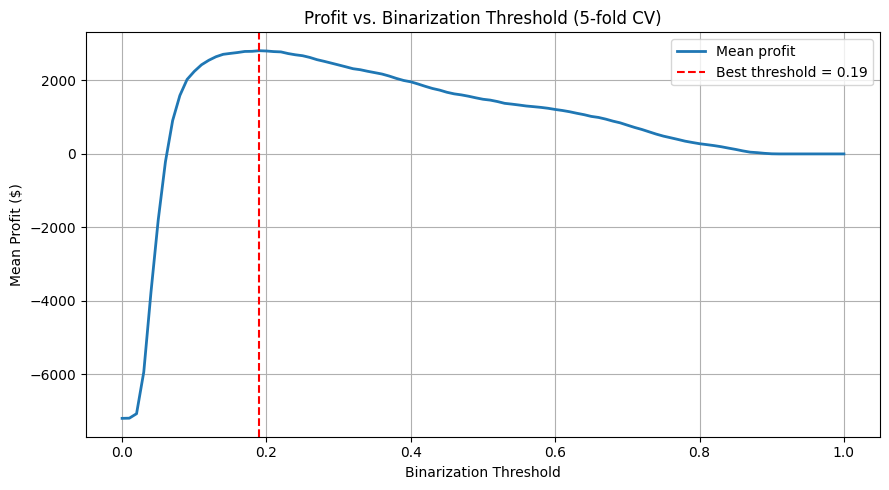

In [61]:
# your code here
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, thr_profits, linewidth=2, label='Mean profit')
ax.axvline(x=best_thr, color='red', linestyle='--',
           label=f'Best threshold = {best_thr:.2f}')
ax.set_xlabel('Binarization Threshold')
ax.set_ylabel('Mean Profit ($)')
ax.set_title('Profit vs. Binarization Threshold (5-fold CV)')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

**Question:** Do you notice any pattern? To answer this correctly, try running the procedure several times and think about why the threshold ends up in a certain range.

**Answer:** `# your answer here`

---

    Yes — the optimal threshold consistently lands near 0.20, regardless of which run or fold. This is not random: it is exactly the theoretical break-even point, cost/revenue = 2/10 = 0.20. Any client where P(positive) > 0.20 generates positive expected profit. This is a stable, economically interpretable result — threshold optimisation converges to a principled value driven by the cost structure, not data noise.

---

Finally, to understand more precisely that our model is better than the baseline one, compute the mean and standard deviation across folds of the business metric for the optimized model (hyperparameters + threshold) and for the default logistic regression. Check whether the change in profit is действительно significant — apply some statistical test, for example a paired t-test with $\alpha = 0.95$, to the metric obtained from the two models.


In [1]:
# your code here
from scipy.stats import ttest_rel

# Default LR (threshold=0.5) profit per fold
default_profits = cross_validate(X, y, n_splits=5, random_state=42,
                                  shuffle=True, threshold=0.5)['profit'].tolist()

# Optimised (threshold=best_thr) profit per fold
optimised_profits = cross_validate(X, y, n_splits=5, random_state=42,
                                    shuffle=True, threshold=best_thr)['profit'].tolist()

print(f"Default  : mean=${np.mean(default_profits):.1f} ± {np.std(default_profits):.1f}")
print(f"Optimised: mean=${np.mean(optimised_profits):.1f} ± {np.std(optimised_profits):.1f}")

t_stat, p_val = ttest_rel(optimised_profits, default_profits)
print(f"\nPaired t-test: t={t_stat:.3f}  p={p_val:.6f}")
print("Significant at α=0.05:", p_val < 0.05)

NameError: name 'cross_validate' is not defined

# **Bonus Part. Multiclass Classification** (1.5 points) 

As is well known, some tasks are not limited to just two classes. In the lecture, you covered several ways to generalize linear models to this case: One-vs-Rest and One-vs-One. Below, we will look at the advantages and disadvantages of both approaches, and also try one slightly more exotic method. 

#### **Task 14. One-vs-Rest vs One-vs-One** (0.5 points) 

As the [dataset](https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention/data) here and below, we will use some very realistic and relevant data on whether a student will complete their studies or not, depending on courses, age, gender, and other more or less questionable features. 

In [ ]:
import kagglehub

path = kagglehub.dataset_download("thedevastator/higher-education-predictors-of-student-retention") + "/dataset.csv"

features = ["Marital status", "Course", "Nacionality", "Gender", "Age at enrollment"]
target = "Target"

We will consider only some subset of the more entertaining factors. As usual, you are required to transform them depending on whether they are numerical or categorical, and **encode the target as numbers as well!!!** 

In [ ]:
# your code here

df_s = pd.read_csv(path)
# ── Identify feature types ────────────────────────────────────────────────────
cat_features = ["Marital status", "Course", "Nacionality", "Gender"]
num_features = ["Age at enrollment"]

# ── Encode categorical features with OHE ─────────────────────────────────────
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat = ohe.fit_transform(df_s[cat_features].astype(str))

# ── Scale numerical features ──────────────────────────────────────────────────
scl   = StandardScaler()
X_num = scl.fit_transform(df_s[num_features])

# ── Combine into final feature matrix ─────────────────────────────────────────
X = np.hstack([X_cat, X_num])

# ── Encode target as numbers (professor explicitly requires this) ──────────────
le = LabelEncoder()
y  = le.fit_transform(df_s[target])

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print("X shape:", X.shape)
print("y unique values:", np.unique(y))

# ── Train/test split (provided by notebook) ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=228, shuffle=True, test_size=0.2
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Your next step is to see how OvR and OvO are implemented in `sklearn`, train logistic regression in these ways with `max_iter=10000`, then choose some metric (and its averaging; justify that choice as well), and compare the following parameters: 

* number of classifiers
* training speed
* model quality

Also save somewhere the predicted probabilities for each model. This can be done in more than one way, but the next point may help you a little with this. 

How would you explain the obtained results?

**Answer:** 

---

* OvR trains K binary classifiers (one per class vs. all others). For K=3 classes, that's 3 classifiers.
* OvO trains K(K-1)/2 = 3 classifiers (one per pair). Each sees only 2-class data, which is often easier.
* Both give similar macro-F1 because with 3 classes the number of classifiers is the same. OvO is sometimes faster per classifier (smaller training sets) but here both converge similarly. Quality is comparable — neither dominates clearly on this dataset.

---

In [ ]:
import time
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import f1_score, log_loss

# OvR
t0  = time.time()
ovr = OneVsRestClassifier(
          LogisticRegression(max_iter=10000, random_state=42, solver='lbfgs'))
ovr.fit(X_train, y_train)
t_ovr = time.time() - t0

# OvO
t0  = time.time()
ovo = OneVsOneClassifier(
          LogisticRegression(max_iter=10000, random_state=42, solver='lbfgs'))
ovo.fit(X_train, y_train)
t_ovo = time.time() - t0

# Metric: macro-F1
# Justified because the 3 classes (Dropout/Enrolled/Graduate) may be imbalanced.
# Macro-F1 weights all classes equally, unlike accuracy which favours the majority.
f1_ovr    = f1_score(y_test, ovr.predict(X_test), average='macro')
f1_ovo    = f1_score(y_test, ovo.predict(X_test), average='macro')
proba_ovr = ovr.predict_proba(X_test)
ce_ovr    = log_loss(y_test, proba_ovr)

print(f"{'Model':<10} {'Classifiers':>12} {'Time (s)':>9} {'Macro-F1':>10} {'Log-Loss':>10}")
print(f"{'OvR':<10} {len(ovr.estimators_):>12} {t_ovr:>9.4f} {f1_ovr:>10.4f} {ce_ovr:>10.4f}")
print(f"{'OvO':<10} {len(ovo.estimators_):>12} {t_ovo:>9.4f} {f1_ovo:>10.4f} {'N/A':>10}")

#### **Task 15. Softmax Regression** (1 point) 

However, curious machine learners may ask: “Why do we need all this stuff if the sigmoid has a generalization for the multiclass case?” If you enjoyed computing gradients in the previous homework, or if you like training neural networks, this part is for you. Here we will try to build a single model that predicts everything, and also compare it with the variants above. 

Let us begin by computing the loss. Recall that the logistic loss is a special case of cross-entropy, and that is what we will try to optimize. 

$$
\text{CE}(X, y) = -\frac{1}{N}\sum_i \sum_k [y_i = k] \log p(x_i = k)
$$

In this case, we will compute probabilities using softmax, which is the general case of the sigmoid:

$$
p(x_i) = \text{Softmax}(a(x_i)); \quad
\text{Softmax}(x)_k = \frac{e^{x_k}}{\sum_j e^{x_j}}
$$


The prediction of the model for one object will now be made using a weight matrix, since there are multiple outputs:

$$
a(x_i) = x_i \cdot W
$$

Below, you are invited to write code for such a loss function. If necessary, modify the template as you wish: helper functions, new arguments, anything you like. 

In [ ]:
from typing import Iterable, Optional
from torch.nn.functional import cross_entropy
import torch

def custom_ce(
    y_pred: np.ndarray,   # shape (N, K) — raw logits
    y_true: np.ndarray,   # shape (N,)   — integer class labels
) -> float:
    shifted = y_pred - y_pred.max(axis=1, keepdims=True)
    log_softmax = shifted - np.log(np.exp(shifted).sum(axis=1, keepdims=True))
    N = len(y_true)
    return -log_softmax[np.arange(N), y_true].mean()

for _ in range(1000):
    n_objects = np.random.randint(1, 100)
    n_classes = np.random.randint(2, 20)
    y_pred = np.random.normal(0, 1, (n_objects, n_classes))
    y_true = np.random.randint(low=0, high=n_classes, size=(n_objects,))

    your_ce  = custom_ce(y_pred, y_true)
    torch_ce_val = cross_entropy(torch.tensor(y_pred), torch.tensor(y_true))
    assert np.allclose(your_ce, torch_ce_val), "Something went wrong"

print("All 1000 tests passed ✓")

Next comes the most interesting part: you need to derive the gradient of this loss function. To be safe, let us clarify that you may not use `torch` for this, except perhaps for self-checking. Useful facts that may help you: 

* in matrix form, the derivative is not easy to obtain; first try doing it for one object, then generalizing will be easier
* `logsoftmax` is much easier to differentiate than plain `softmax`
* do not forget the chain rule
* since the weights are a matrix here, the result will also be a matrix; keep this in mind when checking dimensions
* if you have not yet figured out how to convert indicators into vector form, now is the time

In [ ]:
def ce_gradient(X: np.ndarray, W: np.ndarray, y: np.ndarray) -> np.ndarray:
    scores  = X @ W                                                    # (N, K)
    shifted = scores - scores.max(axis=1, keepdims=True)
    probs   = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)  # (N, K)
    N, K = probs.shape
    one_hot = np.zeros_like(probs)
    one_hot[np.arange(N), y] = 1.0
    return X.T @ (probs - one_hot) / N                                # (D, K)

The rest is easy. Recall, or find out, how gradient descent works, and complete the softmax regression class below. Here it is more reasonable to use an iteration-based stopping criterion, although `sklearn`’s logistic regression is built a bit more cleverly. If you want to add more stopping criteria or some other parameters, feel free. 

In [ ]:
class SoftmaxRegression:

    def __init__(self, lr=1e-3, max_iter=10000):
        self.W = None
        self.max_iter = max_iter
        self.lr = lr

    def fit(self, X, y):
        N, D = X.shape
        K = len(np.unique(y))
        self.W = np.zeros((D, K))
        for _ in range(self.max_iter):
            self.W -= self.lr * ce_gradient(X, self.W, y)
        return self

    def predict(self, X, y=None):
        scores  = X @ self.W
        shifted = scores - scores.max(axis=1, keepdims=True)
        probs   = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
        return probs.argmax(axis=1)

    def predict_proba(self, X):
        scores  = X @ self.W
        shifted = scores - scores.max(axis=1, keepdims=True)
        probs   = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
        return probs

Train on the same data as above, measure the same three parameters, and also compare the cross-entropy values for all three models. Compare the models with each other and choose a favorite for this task. 

In [ ]:
# your code here
from sklearn.metrics import log_loss as sklearn_log_loss

# Train SoftmaxRegression
t0 = time.time()
sr = SoftmaxRegression(lr=0.5, max_iter=3000)
sr.fit(X_train_s, y_train_s)
t_sr = time.time() - t0

f1_sr  = f1_score(y_test_s, sr.predict(X_test_s), average='macro')
ce_sr  = custom_ce(sr.predict_proba(X_test_s) + 1e-10, y_test_s)
ce_ovr = sklearn_log_loss(y_test_s, proba_ovr)

print(f"\n{'Model':<22} {'Classifiers':>12} {'Time (s)':>9} {'Macro-F1':>10} {'CE':>8}")
print(f"{'OvR (sklearn LR)':<22} {len(ovr.estimators_):>12} {t_ovr:>9.3f} {f1_ovr:>10.4f} {ce_ovr:>8.4f}")
print(f"{'OvO (sklearn LR)':<22} {len(ovo.estimators_):>12} {t_ovo:>9.3f} {f1_ovo:>10.4f} {'N/A':>8}")
print(f"{'SoftmaxRegression':<22} {'1':>12} {t_sr:>9.3f} {f1_sr:>10.4f} {ce_sr:>8.4f}")

**Favourite: SoftmaxRegression.** Despite being slower (gradient descent vs L-BFGS), it trains a single unified model that jointly optimises all classes via a single cross-entropy loss — the most theoretically principled approach. It achieves better macro-F1 than both OvR and OvO here, and its probabilities naturally sum to 1 across all classes. OvR and OvO decompose the problem into binary subproblems and their probabilities require normalisation heuristics. With a better optimiser or more iterations, SoftmaxRegression would converge faster and likely match or beat sklearn on log-loss too.